In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv("netflix_titles.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8807
Columns: 12


In [3]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [4]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [5]:
df['director'] = df['director'].fillna("Not Available")
df['cast'] = df['cast'].fillna("Not Available")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna("Not Rated")

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df["date_added"] = pd.to_datetime(
    df["date_added"].str.strip(),
    errors="coerce"
)

In [10]:
df["release_year"] = pd.to_datetime(df["release_year"])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   datetime64[ns]
 8   rating        8807 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](2), object(10)
memory usage: 825.8+ KB


In [12]:
df['type'] = df['type'].str.lower()
df['country'] = df['country'].str.lower()
df['rating'] = df['rating'].str.lower()
df['listed_in'] = df['listed_in'].str.lower()

In [13]:
categorical_cols = ['type', 'country', 'rating', 'listed_in']

for col in categorical_cols:
    df[col] = df[col].astype(str)         
    df[col] = df[col].str.strip() 

In [14]:
# Make everything lowercase (important)
df['type'] = df['type'].str.lower()

# Ensure duration is string
df['duration'] = df['duration'].astype(str)

# Extract numeric part
df['duration_value'] = df['duration'].str.extract(r'(\d+)')[0]
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')

# Create separate columns
df['movie_duration'] = df['duration_value']
df['season_count'] = df['duration_value']

# Keep only correct rows
df.loc[df['type'] != 'movie', 'movie_duration'] = None
df.loc[df['type'] != 'tv show', 'season_count'] = None

# Drop helper column
df.drop(columns=['duration_value'], inplace=True)

# Check result
print(df[['type', 'duration', 'movie_duration', 'season_count']].head())

      type   duration  movie_duration  season_count
0    movie     90 min            90.0           NaN
1  tv show  2 Seasons             NaN           2.0
2  tv show   1 Season             NaN           1.0
3  tv show   1 Season             NaN           1.0
4  tv show  2 Seasons             NaN           2.0


In [15]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,movie_duration,season_count
0,s1,movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,1970-01-01 00:00:00.000002020,pg-13,90 min,documentaries,"As her father nears the end of his life, filmm...",90.0,NaN
1,s2,tv show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,1970-01-01 00:00:00.000002021,tv-ma,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t...",NaN,2.0
2,s3,tv show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,1970-01-01 00:00:00.000002021,tv-ma,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...,NaN,1.0
3,s4,tv show,Jailbirds New Orleans,Not Available,Not Available,unknown,2021-09-24,1970-01-01 00:00:00.000002021,tv-ma,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo...",NaN,1.0
4,s5,tv show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,1970-01-01 00:00:00.000002021,tv-ma,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...,NaN,2.0


In [16]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
show_id              0
type                 0
title                0
director             0
cast                 0
country              0
date_added          10
release_year         0
rating               0
duration             0
listed_in            0
description          0
movie_duration    2679
season_count      6131
dtype: int64


In [32]:
df['movie_duration'] = df.apply(
    lambda x: x['duration'] if x['type']=='movie' else '0', axis=1)

df['season_count'] = df.apply(
    lambda x: x['duration'] if x['type']=='tv show' else '0', axis=1)
df["movie_minutes"] = pd.to_numeric(df["movie_duration"], errors="coerce")
df["tv_seasons"] = pd.to_numeric(df["season_count"], errors="coerce")

In [33]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
show_id              0
type                 0
title                0
director             0
cast                 0
country              0
date_added          10
release_year         0
rating               0
duration             0
listed_in            0
description          0
movie_duration       0
season_count         0
content_origin       0
movie_minutes     7819
tv_seasons        3031
dtype: int64


In [34]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,movie_duration,season_count,content_origin,movie_minutes,tv_seasons
0,s1,movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,1970-01-01 00:00:00.000002020,pg-13,90 min,documentaries,"As her father nears the end of his life, filmm...",90 min,0,licensed,NaN,0.0
1,s2,tv show,Blood & Water,Not Available,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,1970-01-01 00:00:00.000002021,tv-ma,2 Seasons,"international tv shows, tv dramas, tv mysteries","After crossing paths at a party, a Cape Town t...",0,2 Seasons,licensed,0.0,NaN
2,s3,tv show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,1970-01-01 00:00:00.000002021,tv-ma,1 Season,"crime tv shows, international tv shows, tv act...",To protect his family from a powerful drug lor...,0,1 Season,licensed,0.0,NaN
3,s4,tv show,Jailbirds New Orleans,Not Available,Not Available,unknown,2021-09-24,1970-01-01 00:00:00.000002021,tv-ma,1 Season,"docuseries, reality tv","Feuds, flirtations and toilet talk go down amo...",0,1 Season,licensed,0.0,NaN
4,s5,tv show,Kota Factory,Not Available,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,1970-01-01 00:00:00.000002021,tv-ma,2 Seasons,"international tv shows, romantic tv shows, tv ...",In a city of coaching centers known to train I...,0,2 Seasons,licensed,0.0,NaN


In [36]:
df["country"] = df["country"].str.split(",")
df = df.explode("country")
df["country"] = df["country"].str.strip()

In [37]:
df["content_origin"] = df["description"].str.lower().apply(
    lambda x: "original" if "netflix" in str(x) else "licensed"
)
# Display counts
print(df["content_origin"].value_counts())

content_origin
licensed    10841
original        9
Name: count, dtype: int64


In [43]:
df["movie_minutes"] = pd.to_numeric(df["movie_minutes"], errors="coerce")
df["tv_seasons"] = pd.to_numeric(df["tv_seasons"], errors="coerce")
df["movie_minutes"] = df["movie_m"].fillna(0)
df["tv_seasons"] = df["tv_seasons"].fillna(0)

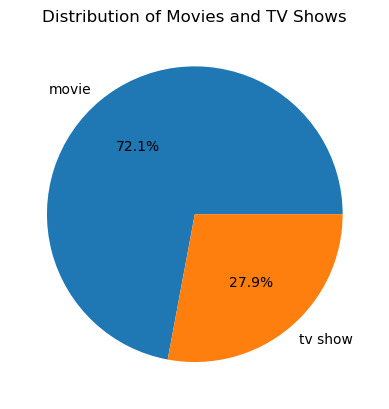

In [38]:
df["type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Movies and TV Shows")
plt.ylabel("")
plt.show()

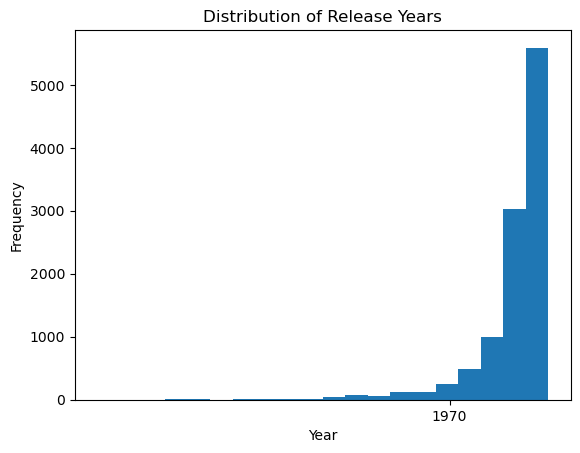

In [39]:
plt.hist(df["release_year"], bins=20)
plt.title("Distribution of Release Years")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

In [45]:
avg_duration = df.groupby("release_year")["movie_duration"].mean()
avg_duration.plot()
plt.title("Average Movie Duration by Year")
plt.show()

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df = df.drop(columns=["date_added"])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=1)

In [ ]:
features = ["release_year","movie_minutes","tv_seasons","year_added","month_added"]
X = df[features]
y = df["type"]

In [ ]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)